# IFN680 Project 5 - main_report

**Group 4** - Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

This notebook reproduces **every number and figure the report carries** for Task 3. It does **not** train: it loads the two checkpoints, the shared held-out test set and the training histories, then compares the Forward and Reverse models across operations, digit positions, carry and borrow cases, answer length and error kind.

Run it top to bottom. It takes a minute or two on CPU, seconds on a GPU.

## Setup

In [1]:
# Same stack as the Week 7 workshop, plus json for the machine readable result dumps.
import json
import math
import pickle
import random
import re


import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

# The brief asks for the GPU environment. The model still runs on CPU when no GPU is visible,
# so the notebook runs unchanged on a machine without one and gives the same answers.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")
print(f"torch  : {torch.__version__}")
print(f"numpy  : {np.__version__}")

# Every result quoted in the report is reproducible from this seed alone, including the
# train/validation/test split, which is regenerated and checked further down.
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
# Bound to _ because manual_seed returns the Generator it just seeded, and a bare call as the
# last line of a cell would store that object's repr as an output.
_ = torch.manual_seed(SEED)

device : cuda
torch  : 2.13.0+cu126
numpy  : 2.5.3


## Step 1: Tokenizer

In [2]:
# The workshop's vocabulary plus one "-" token. That token does double duty: it is the
# subtraction operator inside a prompt ("50-73=") and the negative sign inside a result ("-23").
# Reusing one symbol keeps the vocabulary at 15 and lets position carry the distinction, which
# is something the attention mechanism can learn and an extra token would have hidden.
pad_token = "[PAD]"
eos_token = "[EOS]"


class character_level_tokenizer:
    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "="] + [pad_token, eos_token]
        self.token_to_id = {v: k for k, v in enumerate(self.vocab)}
        self.id_to_token = {k: v for k, v in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)
        # Anything outside the vocabulary is stripped rather than mapped to an unknown token,
        # because every string this model ever sees is generated, not typed by a person.
        self.pattern = f"[^{re.escape(''.join(self.vocab))}]"

    def clean(self, text):
        return re.sub(self.pattern, "", text)

    def pre_tokenization(self, text):
        return [character for character in text]

    def encode(self, text):
        return [self.token_to_id[c] for c in self.pre_tokenization(self.clean(text))]

    def decode(self, token_list):
        return "".join([self.id_to_token[i] for i in token_list])


tokenizer = character_level_tokenizer()
ntokens = tokenizer.ntokens
print(f"ntokens: {ntokens} | vocab: {tokenizer.vocab}")

ntokens: 15 | vocab: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '=', '[PAD]', '[EOS]']


## Step 2: Data for addition and subtraction

Operands are non-negative and at most three digits; a subtraction may be negative when `b > a`. Prompts of the form `-2+3` are out of scope, so no operand ever carries a sign.

In [3]:
def build_dataset(train_size, val_size, test_size, number_digits=3, seed=SEED):
    """Unique, non-overlapping splits with a balanced 50/50 addition and subtraction mix.

    Uniqueness is enforced per operation on the prompt string, then the two streams are
    interleaved and shuffled once before being sliced. Slicing a single shuffled list is what
    makes the three splits disjoint by construction rather than by a later check.
    """
    rng = random.Random(seed)
    total = train_size + val_size + test_size
    per_op = total // 2 + 1

    def unique_for(operation, n):
        seen, out, hi = set(), [], 10 ** number_digits
        while len(out) < n:
            a_int, b_int = rng.randint(0, hi - 1), rng.randint(0, hi - 1)
            prompt = f"{a_int}{operation}{b_int}="
            if prompt in seen:
                continue
            seen.add(prompt)
            # str() of a negative int already carries the leading "-", so the target needs no
            # special casing for b > a.
            result = a_int + b_int if operation == "+" else a_int - b_int
            out.append((prompt, str(result)))
        return out

    additions, subtractions = unique_for("+", per_op), unique_for("-", per_op)
    mixed = []
    for pair_add, pair_sub in zip(additions, subtractions):
        mixed += [pair_add, pair_sub]
    rng.shuffle(mixed)
    return (mixed[:train_size],
            mixed[train_size:train_size + val_size],
            mixed[train_size + val_size:train_size + val_size + test_size])

### Reverse-order transform, parsing, and carry or borrow structure

In [4]:
# Reverse mode reverses the whole answer string literally, so "31" becomes "13" and the units
# digit is emitted first. For a negative result "-123" becomes "321-": the sign lands last,
# which is consistent with right-to-left arithmetic because the sign of a difference is only
# known once the magnitude has been worked out. The brief does not prescribe a rule here, so
# this is a choice, and reversing the string literally is the choice that needs no extra logic.
def to_reverse(text):
    return text[::-1]


def from_reverse(text):
    return text[::-1]


def parse_answer(answer_string, reverse=False):
    """Turn a decoded answer back into an int, un-reversing first when in reverse mode."""
    text = from_reverse(answer_string) if reverse else answer_string
    negative = text.startswith("-")
    digits = "".join(c for c in text if c.isdigit())
    if digits == "":
        return None  # the model emitted no digit at all; counted as an error, never as a zero
    return -int(digits) if negative else int(digits)


def operation_of(prompt):
    return "+" if "+" in prompt else "-"


def carry_positions(a_int, b_int):
    """Units-first flags marking each column of a + b that produces a carry."""
    width = max(len(str(a_int)), len(str(b_int)), len(str(a_int + b_int)))
    left, right = str(a_int).zfill(width), str(b_int).zfill(width)
    carry, flags = 0, []
    for i in reversed(range(width)):
        flags.append(carry)
        carry = 1 if int(left[i]) + int(right[i]) + carry >= 10 else 0
    return flags


def borrow_positions(a_int, b_int):
    """Units-first flags marking each column of a - b that requires a borrow.

    Borrowing is a property of the magnitudes, so the larger operand is put on top first. That
    makes 12-99 and 99-12 share a borrow structure, which is what the arithmetic actually does.
    """
    hi, lo = (a_int, b_int) if a_int >= b_int else (b_int, a_int)
    width = max(len(str(hi)), len(str(lo)))
    top, bottom = str(hi).zfill(width), str(lo).zfill(width)
    borrow, flags = 0, []
    for i in reversed(range(width)):
        upper, lower = int(top[i]) - borrow, int(bottom[i])
        flags.append(1 if upper < lower else 0)
        borrow = 1 if upper < lower else 0
    return flags

## Step 3: Positional encoding

Self-attention sees a set of tokens, not a sequence, so position has to be added to the embedding before the model can tell `12+3` from `21+3`. The fixed sinusoidal encoding of the workshop is kept unchanged. Note what it encodes: where a digit sits in the string, not what place value it holds. Those two coincide for the forward ordering and not for the reverse one.

In [5]:
class PositionalEncoding(nn.Module):
    """Sinusoidal absolute positional encoding, exactly as the workshop defines it.

    Absolute rather than relative positions matter for this project: in reverse mode the model
    has to associate "the position 0 token" with the units digit of an answer whose length it
    has not yet committed to, and that is the comparison Task 2 is asking about.
    """

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp((torch.arange(0, d_model, 2).float() / d_model) * (-math.log(1e4)))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # Stored as (max_len, 1, d_model) to match the (sequence, batch, feature) layout the
        # rest of the notebook uses, and registered as a buffer so it moves with .to(device).
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

## Step 4: Transformer model

A causal decoder. Each position may attend only to positions at or before it, which is what makes it safe to train on every position of a sequence at once: no position can reach the answer it is being asked to predict.

In [6]:
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    """The workshop's encoder layer, which keeps its attention weights for inspection."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    def forward(self, src, src_mask=None, src_key_padding_mask=None, **kwargs):
        src2, attn_weights = self.self_attn(
            src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask,
            need_weights=True, average_attn_weights=False)
        self.attn_weights = attn_weights
        src = self.norm1(src + self.dropout1(src2))
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        return self.norm2(src + self.dropout2(src2))


class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.1):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, dropout)
        # enable_nested_tensor is switched off explicitly. This model runs with
        # batch_first=False, so the nested-tensor fast path is unusable anyway and PyTorch
        # would otherwise emit a UserWarning on every construction.
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers, enable_nested_tensor=False)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    def _generate_square_subsequent_mask(self, size):
        # log of a lower-triangular matrix of ones: 0 where attention is allowed, -inf above the
        # diagonal. Adding it to the attention scores is what makes the model causal.
        return torch.log(torch.tril(torch.ones(size, size)))

    def forward(self, src):
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        src = self.input_emb(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output_enc = self.encoder(src, mask=mask)
        output_dec = self.decoder(output_enc)
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec, dim=-1), output_enc, attention_maps

## Step 5: Generation, padding and batching

Prompts differ in length, so they are padded to a common width before being stacked into a batch. Decoding takes the arg max at every step instead of sampling, which makes a prediction a function of the weights alone and the whole evaluation repeatable.

In [7]:
# Three utilities the workshop keeps separate: decoding, padding, and assembling a batch.
# Each takes the model or the data as an argument, so the same code serves training and
# evaluation and nothing here reads a global.
def generate(model, prompts, new_tokens=6):
    """Greedy autoregressive decoding: append the arg max token, then feed it back in.

    Greedy rather than sampled, so decoding is deterministic: re-running this notebook on
    different hardware gives the same predictions.
    """
    input_tensor = prompts.to(device)
    for _ in range(new_tokens):
        output, _, _ = model(input_tensor)
        token = torch.argmax(output[-1, :, :], -1).view((1, -1))
        input_tensor = torch.cat((input_tensor, token), 0)
    return input_tensor


def pad(token_list, type_list="prompts"):
    """Prompts are left-padded, answers are right-padded after an [EOS].

    Left-padding the prompts keeps the "=" in the same relative place as the generation start,
    so the first predicted token always follows the equals sign whatever the operand widths.
    """
    max_length = max(len(x) for x in token_list)
    out = []
    for x in token_list:
        if type_list == "prompts":
            out.append([tokenizer.token_to_id[pad_token]] * (max_length - len(x)) + x)
        else:
            out.append(x + [tokenizer.token_to_id[eos_token]] +
                       [tokenizer.token_to_id[pad_token]] * (max_length - len(x)))
    return out, max_length


def get_batch(data, i, batch_size, reverse):
    """One batch of (prompt, answer) pairs. `reverse` decides the target's digit order only."""
    j_end = min(i + batch_size, len(data))
    prompts = [tokenizer.encode(data[j][0]) for j in range(i, j_end)]
    padded_prompts, length_prompts = pad(prompts, "prompts")
    answers = [tokenizer.encode(to_reverse(data[j][1]) if reverse else data[j][1])
               for j in range(i, j_end)]
    padded_answers, length_answers = pad(answers, "answers")
    X = torch.stack([torch.tensor(x) for x in padded_prompts], 1)
    Y = torch.stack([torch.tensor(x) for x in padded_answers], 1)
    return X, Y, length_prompts, length_answers

## Step 6: Accuracy metrics

Two levels, because they answer different questions. Digit accuracy counts individual characters and shows how close a wrong answer was; sequence accuracy demands the entire answer and is the one the task is scored on. Sequence accuracy is always the lower of the two, and the gap between them is a measure of how near the misses are.

In [8]:
# Two views of accuracy. evaluate() is the workshop's token-level measure, used to watch
# convergence while training; predict_numeric() decodes to integers, which is what Task 3
# scores, because whether the sum is right is a question about the number not the tokens.
def evaluate(model, input_data, reverse, batch_size=200):
    """Token-level and whole-sequence accuracy, as defined in the workshop.

    The model is passed in rather than read from the enclosing scope, so the same function can
    score the trained model and the ablation model without either of them being a global.
    """
    model.eval()
    correct_digit = total_digit = correct = total = 0.0
    with torch.no_grad():
        for i in range(0, len(input_data), batch_size):
            prompts, targets, length_prompts, length_answers = get_batch(
                input_data, i, batch_size, reverse)
            prompts, targets = prompts.to(device), targets.to(device)
            output = generate(model, prompts, length_answers + 1)
            answers_tokens = output[length_prompts:, :]
            target_mask_pad = targets != tokenizer.token_to_id[pad_token]
            equality_test = answers_tokens == targets
            correct_digit += torch.logical_and(target_mask_pad, equality_test).sum().item()
            total_digit += target_mask_pad.sum().item()
            correct += torch.all(torch.logical_or(~target_mask_pad, equality_test),
                                 axis=0).float().sum().item()
            total += targets.shape[-1]
    return correct_digit / total_digit, correct / total


def predict_numeric(model, input_data, reverse, batch_size=200, new_tokens=6):
    """Decode each prompt to an int. Returns (prompts, true ints, predicted ints).

    A prediction that cannot be parsed stays None rather than becoming 0, so an unparseable
    output is never silently scored as a correct answer to "a - a =".
    """
    model.eval()
    prompts_out, trues, preds = [], [], []
    with torch.no_grad():
        for i in range(0, len(input_data), batch_size):
            chunk = input_data[i:i + batch_size]
            encoded = [tokenizer.encode(p) for p, _ in chunk]
            padded, length_prompts = pad(encoded, "prompts")
            X = torch.stack([torch.tensor(x) for x in padded], 1).to(device)
            generated = generate(model, X, new_tokens)[length_prompts:, :]
            for b, (prompt, target) in enumerate(chunk):
                text = tokenizer.decode(generated[:, b].tolist())
                text = text.split(eos_token)[0].replace(pad_token, "")
                prompts_out.append(prompt)
                trues.append(int(target))
                preds.append(parse_answer(text, reverse=reverse))
    return prompts_out, trues, preds

## Load the shared test set, and verify it

The test set is regenerated from `SEED` and compared against the file that ships in the archive, so both its contents and its disjointness from training are confirmed before any accuracy is computed.

In [9]:
# The held-out set ships with the archive, and is also regenerated from SEED below so a reader
# can confirm the file was not hand-picked after the fact.
with open("project5_testset.pkl", "rb") as handle:
    data_test = pickle.load(handle)

data_train, data_val, regenerated_test = build_dataset(150000, 10000, 10000)
train_prompts = {p for p, _ in data_train} | {p for p, _ in data_val}
overlap = sum(1 for p, _ in data_test if p in train_prompts)
assert data_test == regenerated_test, "the shipped test set differs from the one SEED produces"
assert overlap == 0, f"{overlap} test prompts also appear in train or validation"
assert len(data_test) >= 10000, "the brief asks for a held-out set of at least 10k samples"

n_sub = sum(1 for p, _ in data_test if "-" in p)
print(f"test examples {len(data_test)}  subtraction fraction {n_sub / len(data_test):.2f}")
print(f"regenerates from SEED exactly: True  |  train/test prompt overlap {overlap}")

test examples 10000  subtraction fraction 0.49
regenerates from SEED exactly: True  |  train/test prompt overlap 0


## Load both trained models

In [10]:
# Both checkpoints hold a plain state_dict rather than a pickled module, so the architecture
# is rebuilt here and the weights are loaded into it.
def load_model(path):
    """Rebuild the architecture and load a checkpoint into it.

    dropout is passed explicitly so the loaded model matches the one that was trained; it makes
    no numerical difference under eval() but leaving it to a default would be a discrepancy a
    reader has to chase. weights_only=True refuses to execute anything inside the file.
    """
    model = TransformerModel(ntoken=ntokens, ninp=128, nhead=16, nhid=64, nlayers=6, dropout=0.1)
    model.to(device)
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.eval()
    return model


forward_model = load_model("LLMForward.pth")
reverse_model = load_model("LLMReverse.pth")
n_parameters = sum(p.numel() for p in forward_model.parameters())
print("loaded LLMForward.pth and LLMReverse.pth")
print(f"both models have the same architecture, {n_parameters:,} parameters each")

loaded LLMForward.pth and LLMReverse.pth
both models have the same architecture, 502,671 parameters each


## Predict with both models on the same examples

In [11]:
# Both models are run over the same list in the same order, and the prompts are compared
# afterwards. The paired test further down is only valid if the two really did see identical
# examples, so that condition is confirmed here before anything depends on it.
# reverse= is passed explicitly rather than read from a global, so each call states which
# convention it is decoding under.
prompts, trues, preds_f = predict_numeric(forward_model, data_test, reverse=False)
prompts_r, trues_r, preds_r = predict_numeric(reverse_model, data_test, reverse=True)
assert prompts == prompts_r and trues == trues_r, "the two models saw different examples"
print(f"predicted {len(prompts)} examples with each model")

predicted 10000 examples with each model


## Statistical helpers

Two tools, for two different questions. A Wilson interval puts a range around a single accuracy; it is used instead of the textbook normal interval because these rates sit hard against the boundary at 1.0, where the normal interval runs past it and stops meaning anything. McNemar's exact test compares the two models, and it is the correct test here because both answered the same examples, so only the cases where they disagree carry information.

In [12]:
# Accuracy over 10,000 examples still carries sampling error, and both models were scored on
# the same examples. These functions turn a comparison of two point estimates into a
# statement about whether the difference between them is real.
def wilson_interval(successes, n, z=1.96):
    """95% confidence interval for a proportion.

    Wilson rather than the textbook normal interval because these accuracies sit against the
    boundary at 1.0, where the normal interval runs past it and stops being meaningful.
    """
    if n == 0:
        return (float("nan"), float("nan"))
    p = successes / n
    denominator = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denominator
    margin = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denominator
    return (max(0.0, centre - margin), min(1.0, centre + margin))


def mcnemar_exact(preds_a, preds_b):
    """Two-sided exact McNemar test on paired predictions.

    Both models answered the same examples, so the comparison is paired and only the cases
    where they disagree carry information. b and c below are those two disagreement counts.
    """
    b = sum(1 for t, x, y in zip(trues, preds_a, preds_b) if x == t and y != t)
    c = sum(1 for t, x, y in zip(trues, preds_a, preds_b) if x != t and y == t)
    n = b + c
    if n == 0:
        return b, c, 1.0
    tail = sum(math.comb(n, k) for k in range(0, min(b, c) + 1)) * (0.5 ** n)
    return b, c, min(1.0, 2 * tail)


def is_correct(prediction, truth):
    return prediction is not None and prediction == truth

## Operation robustness: overall and per-operation accuracy

The headline number for each model, then the same number split by operation. The split matters because subtraction is the harder half: it borrows, and it can produce a negative answer, so a model that looks strong overall can still be carrying most of its errors on one side.

In [13]:
# Overall and per-operation accuracy, with the count behind each rate and a Wilson interval.
# The interval is what shows whether the margin above the target is larger than sampling error.
print(f"{'mode':>8} | {'split':>12} | {'n':>6} | {'correct':>7} | {'accuracy':>8} | {'95% CI':>16}")
# Keyed (mode, split) so any single cell of this table can be looked up by name below.
results_table = {}
for name, preds in [("Forward", preds_f), ("Reverse", preds_r)]:
    for split in ["overall", "addition", "subtraction"]:
        if split == "overall":
            index = range(len(trues))
        else:
            symbol = "+" if split == "addition" else "-"
            index = [i for i in range(len(trues)) if operation_of(prompts[i]) == symbol]
        correct = sum(1 for i in index if is_correct(preds[i], trues[i]))
        n = len(index)
        low, high = wilson_interval(correct, n)
        results_table[(name, split)] = (correct, n, correct / n, low, high)
        print(f"{name:>8} | {split:>12} | {n:>6} | {correct:>7} | {correct / n:>8.4f} | "
              f"[{low:.4f}, {high:.4f}]")

# The task sets 0.78 as the level both models have to clear. Asserting it makes the
# notebook stop if a re-run ever falls below it, instead of quietly reporting a lower number.
for name in ["Forward", "Reverse"]:
    assert results_table[(name, "overall")][2] > 0.78, f"{name} is below the target"
print(f"\nboth models exceed the 0.78 target on the held-out set")

    mode |        split |      n | correct | accuracy |           95% CI
 Forward |      overall |  10000 |    9993 |   0.9993 | [0.9986, 0.9997]
 Forward |     addition |   5076 |    5076 |   1.0000 | [0.9992, 1.0000]
 Forward |  subtraction |   4924 |    4917 |   0.9986 | [0.9971, 0.9993]
 Reverse |      overall |  10000 |    9956 |   0.9956 | [0.9941, 0.9967]
 Reverse |     addition |   5076 |    5049 |   0.9947 | [0.9923, 0.9963]
 Reverse |  subtraction |   4924 |    4907 |   0.9965 | [0.9945, 0.9978]

both models exceed the 0.78 target on the held-out set


## The same predictions scored over tokens

The workshop scored this task position by position over the answer's tokens, counting a sequence correct only when every position matched. Task 3 scores the integer instead. Both are reported here, because they ask the same question and should very nearly agree, and because the digit rate is the finer view of how wrong a wrong answer was.

In [14]:
# evaluate() is the measure the workshop trained against: it compares the generated answer
# position by position and counts a sequence correct only when every position matches. Task 3
# asks whether the number is right, which is what the table above reports. These are two
# different questions about the same predictions and they should very nearly agree, because a
# token sequence that matches everywhere decodes to the same integer. They need not agree
# exactly: a prediction that runs past the end of its target fails the token test and can still
# parse to the right number. The gap below is what says how often that happened, and a gap of
# zero means every sequence one definition accepted the other accepted too. The digit rate is
# the part the integer view cannot show, which is how much of a wrong answer was still right.
print(f"{'token level':>11} | {'mode':>8} | {'digit':>9} | {'sequence':>9} | {'numeric':>9}")
gaps = []
for name, model, reverse in [("Forward", forward_model, False),
                             ("Reverse", reverse_model, True)]:
    digit_accuracy, sequence_accuracy = evaluate(model, data_test, reverse)
    numeric_accuracy = results_table[(name, "overall")][2]
    gaps.append(abs(sequence_accuracy - numeric_accuracy))
    print(f"{'token level':>11} | {name:>8} | {digit_accuracy:>9.4f} | "
          f"{sequence_accuracy:>9.4f} | {numeric_accuracy:>9.4f}")

# A scoring mistake, the reverse flag handed to the wrong model for instance, would move these
# two definitions apart by far more than the handful of examples they can legitimately differ
# on, so the tolerance is loose enough to be about bugs rather than about definitions.
assert max(gaps) < 0.005, f"token and integer scoring disagree by {max(gaps):.4f}"
print(f"largest gap between token-level and integer-level sequence accuracy: {max(gaps):.4f}")

token level |     mode |     digit |  sequence |   numeric


token level |  Forward |    0.9998 |    0.9993 |    0.9993


token level |  Reverse |    0.9987 |    0.9956 |    0.9956
largest gap between token-level and integer-level sequence accuracy: 0.0000


## Direction effects: a paired test

Comparing two accuracies measured on the same examples is not the same as comparing two independent samples. The pairing removes the variation caused by which examples happened to be drawn, leaving only the cases the two models answer differently.

In [15]:
# Does direction change accuracy? The two models answered identical examples, so the paired
# test is the right one and it needs only the two disagreement counts.
b, c, p_value = mcnemar_exact(preds_f, preds_r)
print(f"Forward right, Reverse wrong : {b}")
print(f"Forward wrong, Reverse right : {c}")
print(f"both models agree on         : {len(trues) - b - c} of {len(trues)} examples")
print(f"exact McNemar two-sided p    : {p_value:.3e}")

Forward right, Reverse wrong : 44
Forward wrong, Reverse right : 7
both models agree on         : 9949 of 10000 examples
exact McNemar two-sided p    : 1.212e-07


## Digit-level performance

A sequence is either right or wrong, which hides how close a wrong answer came. Scoring each place value separately shows where a model loses a digit. Each place is counted only over answers long enough to have it: zero-padding every answer to four digits would mark the thousands place correct for every two-digit answer and drive the high positions to 1.0 by construction.

In [16]:
def position_accuracy(preds, index=None):
    """Per-place accuracy, counted only over answers that HAVE that place.

    Zero-padding every answer to four digits would score the thousands place as correct for
    every two-digit answer, which inflates the high positions towards 1.0 by construction. Each
    position is therefore measured only on the answers long enough to reach it. The sign is a
    separate question and is measured over everything.

    index restricts the measurement to a subset of the test set, which is how the split by
    operation below reuses this function without duplicating the counting logic.
    """
    labels = ["thousands", "hundreds", "tens", "units"]
    correct = {k: 0 for k in labels}
    total = {k: 0 for k in labels}
    sign_correct = 0
    rows = list(range(len(trues))) if index is None else list(index)
    for row in rows:
        truth, prediction = trues[row], preds[row]
        digits_true = str(abs(truth))
        digits_pred = str(abs(prediction)) if prediction is not None else ""
        width = len(digits_true)
        for offset, label in enumerate(labels[4 - width:]):
            total[label] += 1
            # Compare the same place value, counting from the units end of each string.
            place = width - offset - 1
            got = digits_pred[len(digits_pred) - place - 1] if len(digits_pred) > place else None
            correct[label] += (got == digits_true[offset])
        sign_correct += (prediction is not None and (prediction < 0) == (truth < 0))
    accuracy = {k: (correct[k] / total[k] if total[k] else float("nan")) for k in labels}
    accuracy["sign"] = sign_correct / len(rows) if rows else float("nan")
    total["sign"] = len(rows)
    return accuracy, total


# n differs per position: only answers long enough to have a thousands digit are counted
# towards the thousands row, which is why the counts fall as the place value rises.
acc_f, n_f = position_accuracy(preds_f)
acc_r, n_r = position_accuracy(preds_r)
PLACES = ["thousands", "hundreds", "tens", "units", "sign"]
print(f"{'position':>10} | {'n':>6} | {'Forward':>8} | {'Reverse':>8}")
for label in PLACES:
    print(f"{label:>10} | {n_f[label]:>6} | {acc_f[label]:>8.4f} | {acc_r[label]:>8.4f}")

# The same measurement split by operation, which the task asks for alongside the split by mode.
# Note what the thousands row does here: both operands are at most three digits, so a difference
# can never exceed 999 and no subtraction answer has a thousands digit at all. That cell is empty
# by construction, and printing n/a says so rather than implying a rate of zero.
add_index = [i for i in range(len(trues)) if operation_of(prompts[i]) == "+"]
sub_index = [i for i in range(len(trues)) if operation_of(prompts[i]) == "-"]
acc_fa, n_add = position_accuracy(preds_f, add_index)
acc_ra, _ = position_accuracy(preds_r, add_index)
acc_fs, n_sub = position_accuracy(preds_f, sub_index)
acc_rs, _ = position_accuracy(preds_r, sub_index)


def rate(value, n):
    """Format a rate, or n/a when the group it would describe is empty."""
    return f"{value:8.4f}" if n else f"{'n/a':>8}"


print()
print(f"{'position':>10} | {'n add':>6} | {'Fwd add':>8} | {'Rev add':>8} | "
      f"{'n sub':>6} | {'Fwd sub':>8} | {'Rev sub':>8}")
for label in PLACES:
    print(f"{label:>10} | {n_add[label]:>6} | {rate(acc_fa[label], n_add[label])} | "
          f"{rate(acc_ra[label], n_add[label])} | {n_sub[label]:>6} | "
          f"{rate(acc_fs[label], n_sub[label])} | {rate(acc_rs[label], n_sub[label])}")

  position |      n |  Forward |  Reverse
 thousands |   2490 |   1.0000 |   1.0000
  hundreds |   9045 |   1.0000 |   0.9996
      tens |   9908 |   1.0000 |   0.9959
     units |  10000 |   0.9993 |   0.9991
      sign |  10000 |   1.0000 |   1.0000

  position |  n add |  Fwd add |  Rev add |  n sub |  Fwd sub |  Rev sub
 thousands |   2490 |   1.0000 |   1.0000 |      0 |      n/a |      n/a
  hundreds |   5052 |   1.0000 |   0.9994 |   3993 |   1.0000 |   0.9997
      tens |   5076 |   1.0000 |   0.9951 |   4832 |   1.0000 |   0.9967
     units |   5076 |   1.0000 |   0.9994 |   4924 |   0.9986 |   0.9988
      sign |   5076 |   1.0000 |   1.0000 |   4924 |   1.0000 |   1.0000


## Carry and borrow cases

A carry or a borrow is a column whose result depends on the column beside it, which is exactly the dependency the two orderings treat differently. Forward emits the most significant digit first, before the carries underneath it have been worked out. Reverse emits the units digit first, travelling in the same direction a carry does by hand.

In [17]:
# The columns the brief calls hard. Errors are printed beside accuracies because at these
# rates the counts are the readable quantity: 0.996 and 1.000 look alike, 18 and 0 do not.
def carry_borrow_accuracy(preds):
    """Accuracy split by whether a column carries (addition) or borrows (subtraction)."""
    result = {}
    for symbol, flag_function in [("+", carry_positions), ("-", borrow_positions)]:
        name = "carry" if symbol == "+" else "borrow"
        buckets = {f"with_{name}": [0, 0], f"no_{name}": [0, 0]}
        for i, prompt in enumerate(prompts):
            if operation_of(prompt) != symbol:
                continue
            a_int, b_int = (int(x) for x in prompt[:-1].split(symbol))
            key = f"with_{name}" if sum(flag_function(a_int, b_int)) > 0 else f"no_{name}"
            buckets[key][1] += 1
            buckets[key][0] += is_correct(preds[i], trues[i])
        result[name] = buckets
    return result


cb_f, cb_r = carry_borrow_accuracy(preds_f), carry_borrow_accuracy(preds_r)
header = f"{'case':>14} | {'n':>5} | {'Fwd err':>7} | {'Fwd acc':>8}"
print(header + f" | {'Rev err':>7} | {'Rev acc':>8}")
for group in ["carry", "borrow"]:
    for key in cb_f[group]:
        (fc, fn), (rc, rn) = cb_f[group][key], cb_r[group][key]
        print(f"{key:>14} | {fn:>5} | {fn - fc:>7} | {fc / fn:>8.4f} | "
              f"{rn - rc:>7} | {rc / rn:>8.4f}")

          case |     n | Fwd err |  Fwd acc | Rev err |  Rev acc
    with_carry |  4226 |       0 |   1.0000 |      18 |   0.9957
      no_carry |   850 |       0 |   1.0000 |       9 |   0.9894
   with_borrow |  3322 |       6 |   0.9982 |      11 |   0.9967
     no_borrow |  1602 |       1 |   0.9994 |       6 |   0.9963


## Errors by answer length and sign

Answer length stands in for how much a model has to commit to before it writes anything: predicting left to right means choosing how many digits the answer has first. The sign is the mirror case, since the reverse ordering places it last, after the entire magnitude has been emitted.

In [18]:
# The brief asks which cases fail, and result length is the other axis the errors could follow.
# Negative answers are separated out because they are the only ones carrying a sign token.
print(f"{'group':>16} | {'n':>6} | {'Fwd err':>8} | {'Rev err':>8}")
length_rows = {}
for width in [1, 2, 3, 4]:
    index = [i for i in range(len(trues)) if len(str(abs(trues[i]))) == width]
    if not index:
        continue
    fe = sum(1 for i in index if not is_correct(preds_f[i], trues[i]))
    re_ = sum(1 for i in index if not is_correct(preds_r[i], trues[i]))
    length_rows[f"{width} digit"] = (len(index), fe, re_)
    print(f"{str(width) + ' digit':>16} | {len(index):>6} | {fe:>8} | {re_:>8}")
for label, test in [("negative", lambda t: t < 0), ("non-negative", lambda t: t >= 0)]:
    index = [i for i in range(len(trues)) if test(trues[i])]
    fe = sum(1 for i in index if not is_correct(preds_f[i], trues[i]))
    re_ = sum(1 for i in index if not is_correct(preds_r[i], trues[i]))
    length_rows[label] = (len(index), fe, re_)
    print(f"{label:>16} | {len(index):>6} | {fe:>8} | {re_:>8}")

           group |      n |  Fwd err |  Rev err
         1 digit |     92 |        7 |        0
         2 digit |    863 |        0 |        3
         3 digit |   6555 |        0 |       41
         4 digit |   2490 |        0 |        0
        negative |   2510 |        1 |        0
    non-negative |   7490 |        6 |       44


## Where each direction actually breaks

The two orderings make different things hard. Left to right has to settle the answer's length before emitting a digit; right to left has to keep track of the columns once the shorter operand has run out. The two cuts below test exactly those two predictions.

In [19]:
# The single most informative cut of the errors. Each direction is hypothesised to fail at what
# its own ordering makes hard: left-to-right has to fix the answer's LENGTH before emitting any
# digit, while right-to-left has to notice when the shorter operand runs out of digits. Operand
# width difference tests the second hypothesis and answer length tests the first.
def width_difference(prompt):
    symbol = operation_of(prompt)
    left, right = (int(x) for x in prompt[:-1].split(symbol))
    return len(str(left)) - len(str(right))


print(f"{'len(a)-len(b)':>14} | {'n':>6} | {'Fwd err':>8} | {'Fwd rate':>9} | "
      f"{'Rev err':>8} | {'Rev rate':>9}")
alignment_rows = {}
for difference in sorted({width_difference(p) for p in prompts}):
    index = [i for i in range(len(trues)) if width_difference(prompts[i]) == difference]
    fe = sum(1 for i in index if not is_correct(preds_f[i], trues[i]))
    re_ = sum(1 for i in index if not is_correct(preds_r[i], trues[i]))
    alignment_rows[difference] = (len(index), fe, re_)
    print(f"{difference:>14} | {len(index):>6} | {fe:>8} | {fe / len(index):>9.4f} | "
          f"{re_:>8} | {re_ / len(index):>9.4f}")

# Which place value is actually wrong, counted from the units end. In reverse mode the units
# digit is emitted first, so a failure at place 1 means the model lost track one step in.
place_errors = {"Forward": {}, "Reverse": {}}
for name, preds in [("Forward", preds_f), ("Reverse", preds_r)]:
    for i in range(len(trues)):
        if is_correct(preds[i], trues[i]):
            continue
        if preds[i] is None:
            place_errors[name]["unparseable"] = place_errors[name].get("unparseable", 0) + 1
            continue
        true_digits, pred_digits = str(abs(trues[i])), str(abs(preds[i]))
        if len(true_digits) != len(pred_digits):
            place_errors[name]["wrong length"] = place_errors[name].get("wrong length", 0) + 1
            continue
        for k, (x, y) in enumerate(zip(true_digits, pred_digits)):
            if x != y:
                key = f"place {len(true_digits) - k - 1}"
                place_errors[name][key] = place_errors[name].get(key, 0) + 1
print()
for name in ["Forward", "Reverse"]:
    print(f"{name:>8} wrong places (0 = units): "
          f"{dict(sorted(place_errors[name].items()))}")

# How far off the wrong answers are. An error of exactly one unit is a different failure from
# an answer with the wrong number of digits.
for name, preds in [("Forward", preds_f), ("Reverse", preds_r)]:
    wrong = [i for i in range(len(trues)) if not is_correct(preds[i], trues[i])]
    off_by_one = sum(1 for i in wrong if preds[i] is not None and abs(preds[i] - trues[i]) == 1)
    print(f"{name:>8} errors off by exactly 1: {off_by_one} of {len(wrong)}")

 len(a)-len(b) |      n |  Fwd err |  Fwd rate |  Rev err |  Rev rate
            -2 |     84 |        0 |    0.0000 |        0 |    0.0000
            -1 |    818 |        0 |    0.0000 |        0 |    0.0000
             0 |   8187 |        7 |    0.0009 |        0 |    0.0000
             1 |    819 |        0 |    0.0000 |        2 |    0.0024
             2 |     92 |        0 |    0.0000 |       42 |    0.4565

 Forward wrong places (0 = units): {'place 0': 7}
 Reverse wrong places (0 = units): {'place 0': 9, 'place 1': 38, 'place 2': 2, 'wrong length': 3}
 Forward errors off by exactly 1: 7 of 7
 Reverse errors off by exactly 1: 3 of 44


## Error patterns: every error, and what kind it is

Both models make few enough mistakes to list in full. Each is classified by what went wrong, so the failures can be counted by kind as well as read individually, and so a claim about them can be checked against the complete list rather than a sample.

In [20]:
def describe_error(index, prediction):
    """Classify one wrong answer so the failures can be counted by kind, not just listed."""
    truth = trues[index]
    if prediction is None:
        return "unparseable"
    if (prediction < 0) != (truth < 0):
        return "wrong sign"
    if len(str(abs(prediction))) != len(str(abs(truth))):
        return "wrong length"
    differing = sum(1 for x, y in zip(str(abs(truth)), str(abs(prediction))) if x != y)
    return "single digit slip" if differing == 1 else f"{differing} digit slips"


# Concrete mispredictions, not only rates: this is what the error patterns section of the
# report is written from, and it is the part a reader can check by hand.
print(f"{'mode':>8} | {'prompt':>12} | {'true':>7} | {'predicted':>10} | {'kind':>18}")
error_kinds = {"Forward": {}, "Reverse": {}}
for name, preds in [("Forward", preds_f), ("Reverse", preds_r)]:
    wrong = [i for i in range(len(trues)) if not is_correct(preds[i], trues[i])]
    for i in wrong:
        kind = describe_error(i, preds[i])
        error_kinds[name][kind] = error_kinds[name].get(kind, 0) + 1
    # Both models make few enough errors to print in full, and printing all of them is what
    # lets the report's table of example failures be checked against the complete list.
    for i in wrong:
        print(f"{name:>8} | {prompts[i]:>12} | {trues[i]:>7} | {str(preds[i]):>10} | "
              f"{describe_error(i, preds[i]):>18}")
    print(f"{name}: {len(wrong)} errors in {len(trues)} examples")

print()
for name in ["Forward", "Reverse"]:
    for kind, count in sorted(error_kinds[name].items(), key=lambda x: -x[1]):
        print(f"{name:>8} error kind {kind:>18} : {count}")

    mode |       prompt |    true |  predicted |               kind
 Forward |     505-496= |       9 |          8 |  single digit slip
 Forward |     487-479= |       8 |          7 |  single digit slip
 Forward |     199-200= |      -1 |         -2 |  single digit slip
 Forward |     907-899= |       8 |          7 |  single digit slip
 Forward |     230-228= |       2 |          3 |  single digit slip
 Forward |       88-80= |       8 |          7 |  single digit slip
 Forward |     671-668= |       3 |          4 |  single digit slip
Forward: 7 errors in 10000 examples
 Reverse |       309-0= |     309 |        319 |  single digit slip
 Reverse |       195+2= |     197 |        187 |  single digit slip
 Reverse |       809+1= |     810 |        800 |  single digit slip
 Reverse |       730-8= |     722 |        733 |      2 digit slips
 Reverse |       809+3= |     812 |        802 |  single digit slip
 Reverse |       158+1= |     159 |        158 |  single digit slip
 Reverse |  

## Learning curves from the training runs

The histories saved by the two training notebooks, reloaded here so that every figure the report carries is produced by this one notebook. Each direction was trained twice, on the full set and on a reduced one, which is what separates the effect of data volume from the effect of ordering.

In [21]:
# The learning curves come from the JSON the training notebooks wrote, which is how this
# notebook reports on training without containing a training loop.
# Four runs: two directions at two training set sizes.
histories = {}
for mode in ["Forward", "Reverse"]:
    for size in ["", "_80k"]:
        path = f"LLM{mode}_history{size}.json"
        with open(path) as handle:
            histories[(mode, size or "_full")] = json.load(handle)


def first_epoch_reaching(curve, level):
    """1-based epoch at which the curve first reaches `level`, or None if it never does."""
    for epoch, value in enumerate(curve, start=1):
        if value >= level:
            return epoch
    return None


# Epochs-to-threshold is the learnability measure; the final column is the accuracy the
# run settled at, so a slow start and a poor finish can be told apart.
print(f"{'mode':>8} | {'train size':>10} | {'ep>=tgt':>9} | {'ep>=0.95':>9} | {'final':>7}")
curve_rows = {}
for (mode, size), history in histories.items():
    curve = history["val_seq"]
    row = (first_epoch_reaching(curve, 0.78), first_epoch_reaching(curve, 0.95), curve[-1])
    curve_rows[(mode, size)] = row
    label = "150000" if size == "_full" else "80000"
    print(f"{mode:>8} | {label:>10} | {str(row[0]):>9} | {str(row[1]):>9} | {row[2]:>7.4f}")

# An epoch is not a fixed amount of training: a smaller training set is fewer batches, so the
# same number of epochs is a shorter run. The training notebooks used a batch size of 100,
# which makes the full set 150000 // 100 updates per epoch and the reduced set
# 80000 // 100. Converting epochs to updates is what separates a run that needed
# more training from one that only needed more passes over less data.
train_batch_size = 100
batches_per_epoch = {"_full": 150000 // train_batch_size,
                     "_80k": 80000 // train_batch_size}
# Both directions have to have been trained over the same number of epochs, or the epoch axis
# the rows above compare them on is not a single axis. The count comes from the curves
# themselves, one entry per epoch, rather than from anything typed here.
epochs_trained = {mode: len(histories[(mode, "_full")]["val_seq"])
                  for mode in ["Forward", "Reverse"]}
assert len(set(epochs_trained.values())) == 1, f"epochs differ: {epochs_trained}"
print(f"training: {epochs_trained['Forward']} epochs, batch size {train_batch_size}")
for (mode, size), row in curve_rows.items():
    epoch_at_95 = row[1]
    steps = epoch_at_95 * batches_per_epoch[size] if epoch_at_95 is not None else None
    label = "150000" if size == "_full" else "80000"
    print(f"steps to 0.95 | {mode:>8} | {label:>7} | {str(steps):>8}")

    mode | train size |   ep>=tgt |  ep>=0.95 |   final
 Forward |     150000 |         7 |         8 |  0.9997
 Forward |      80000 |        14 |        15 |  0.9945
 Reverse |     150000 |        18 |        19 |  0.9949
 Reverse |      80000 |      None |      None |  0.0979
training: 30 epochs, batch size 100
steps to 0.95 |  Forward |  150000 |    12000
steps to 0.95 |  Forward |   80000 |    12000
steps to 0.95 |  Reverse |  150000 |    28500
steps to 0.95 |  Reverse |   80000 |     None


## Figure 1 for the report

Three panels: convergence, errors by carry and borrow case, and wrong digits by place value. The right two panels plot counts instead of rates, because every accuracy here is above 0.98 and bars of near-identical rates would look identical.

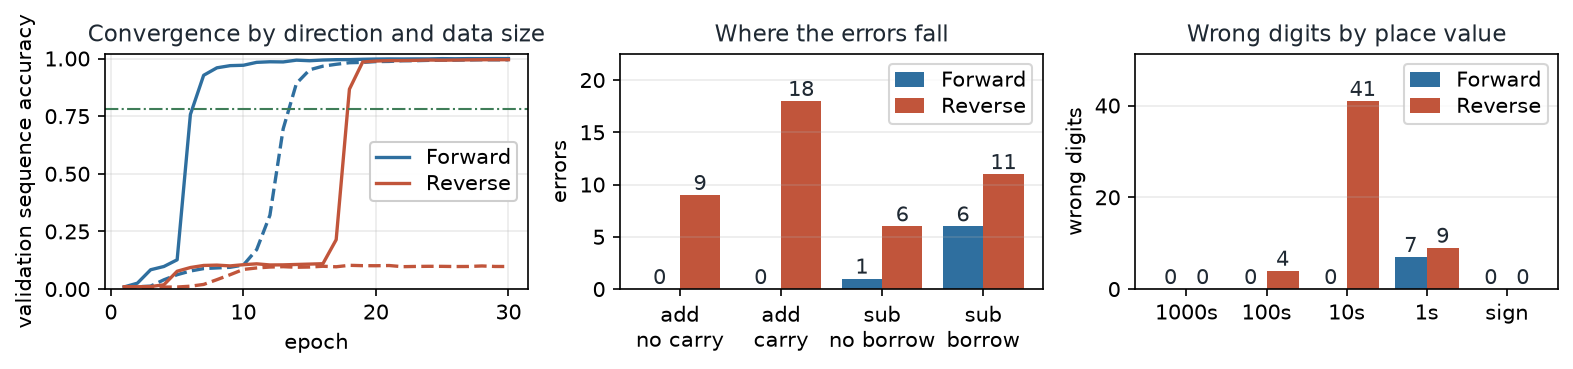

In [22]:
INK, ACCENT, WARM = "#1f2933", "#2f6f9f", "#c1553b"
MUTED, PALE, GREEN = "#7b8794", "#e8ecf1", "#3f7d58"

# Figure 1 for the report. Counts rather than accuracies in the right two panels: every accuracy
# here is above 0.98, so a bar chart of rates renders the two models as identical rectangles,
# while the error counts differ by an order of magnitude and are legible.
# figsize sets how big the labels end up. The report places this at 6.95 in across both
# columns, so every size below is multiplied by roughly 0.67 on the page: 10 pt here renders
# near 6.7 pt, which is the smallest that stays comfortable beside 10 pt body text. The height
# is kept tight because this figure spans both columns, so every inch of it costs two inches
# of text.
fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.5), dpi=150)

# Left panel: convergence. Solid is the full training set, dashed the reduced one.
ax = axes[0]
for mode, colour in [("Forward", ACCENT), ("Reverse", WARM)]:
    for size, style in [("_full", "-"), ("_80k", "--")]:
        curve = histories[(mode, size)]["val_seq"]
        # Only the full-set curves are labelled. Colour is the direction and the line style is
        # the training set size, so naming all four would state the colour key twice and make
        # the box wider than the empty part of the panel, which put it over the curves.
        ax.plot(range(1, len(curve) + 1), curve, style, color=colour, lw=1.6,
                label=mode if size == "_full" else None)
ax.axhline(0.78, color=GREEN, lw=1.0, ls="-.")
ax.set_xlabel("epoch")
ax.set_ylabel("validation sequence accuracy")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
# Centre right is the only part of this panel no curve passes through: everything has either
# reached 1.0 by then or, for the reduced reverse run, stayed near 0.1 throughout.
ax.legend(fontsize=10, loc="center right", labelspacing=0.25, handlelength=1.6,
          borderpad=0.3, framealpha=0.95)
ax.set_title("Convergence by direction and data size", fontsize=11, color=INK)

ax = axes[1]
# Two line tick labels: at the width this figure is embedded, the carry and borrow
# names collide when set on one line.
categories = [("add\nno carry", "carry", "no_carry"),
              ("add\ncarry", "carry", "with_carry"),
              ("sub\nno borrow", "borrow", "no_borrow"),
              ("sub\nborrow", "borrow", "with_borrow")]
x = np.arange(len(categories))
errors_f = [cb_f[g][k][1] - cb_f[g][k][0] for _, g, k in categories]
errors_r = [cb_r[g][k][1] - cb_r[g][k][0] for _, g, k in categories]
ax.bar(x - 0.2, errors_f, 0.4, color=ACCENT, label="Forward")
ax.bar(x + 0.2, errors_r, 0.4, color=WARM, label="Reverse")
for xi, value in zip(x - 0.2, errors_f):
    ax.text(xi, value, str(value), ha="center", va="bottom", fontsize=10, color=INK)
for xi, value in zip(x + 0.2, errors_r):
    ax.text(xi, value, str(value), ha="center", va="bottom", fontsize=10, color=INK)
ax.set_xticks(x)
ax.set_xticklabels([c[0] for c in categories], fontsize=10)
ax.set_ylabel("errors")
ax.set_ylim(0, max(errors_f + errors_r) * 1.25)
ax.grid(alpha=0.25, axis="y")
ax.legend(fontsize=10, labelspacing=0.25, handlelength=1.4, borderpad=0.3)
ax.set_title("Where the errors fall", fontsize=11, color=INK)

ax = axes[2]
labels = ["thousands", "hundreds", "tens", "units", "sign"]
# Abbreviated on the axis only. Set large enough to read once the figure is scaled into the
# report, the five full words overlap; the keys above stay spelled out.
tick_labels = ["1000s", "100s", "10s", "1s", "sign"]
wrong_f = [round((1 - acc_f[k]) * n_f[k]) for k in labels]
wrong_r = [round((1 - acc_r[k]) * n_r[k]) for k in labels]
x = np.arange(len(labels))
ax.bar(x - 0.2, wrong_f, 0.4, color=ACCENT, label="Forward")
ax.bar(x + 0.2, wrong_r, 0.4, color=WARM, label="Reverse")
for xi, value in zip(x - 0.2, wrong_f):
    ax.text(xi, value, str(value), ha="center", va="bottom", fontsize=10, color=INK)
for xi, value in zip(x + 0.2, wrong_r):
    ax.text(xi, value, str(value), ha="center", va="bottom", fontsize=10, color=INK)
ax.set_xticks(x)
ax.set_xticklabels(tick_labels, fontsize=10)
ax.set_ylabel("wrong digits")
ax.set_ylim(0, max(wrong_f + wrong_r) * 1.25)
ax.grid(alpha=0.25, axis="y")
ax.legend(fontsize=10, labelspacing=0.25, handlelength=1.4, borderpad=0.3)
ax.set_title("Wrong digits by place value", fontsize=11, color=INK)

plt.tight_layout()
plt.savefig("figure_1_overview.pdf", bbox_inches="tight")
plt.show()

## Figure 2 for the report

The same errors cut by the shape of the answer rather than by the operation: how many digits it has, and whether it is negative.

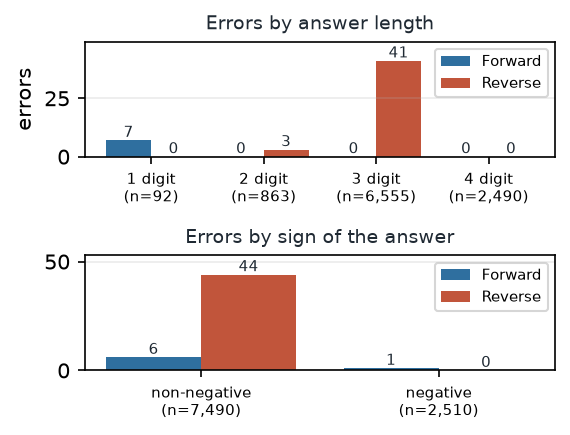

In [23]:
# Figure 2: the same errors cut by how long the answer is and whether it is negative, which is
# the axis the brief calls "longer strings".
# Placed in a single column at 3.47 in against a native 3.8, so the scale here is about 0.91
# and 7 pt renders near 6.4 pt. The height is trimmed to what two small bar panels need.
fig, axes = plt.subplots(2, 1, figsize=(3.9, 3.0), dpi=150)

# Left panel: how long the answer is. Right panel: whether it is negative, which is the
# only case carrying a sign token and the only one reverse mode emits last.
digit_rows = [k for k in length_rows if k.endswith("digit")]
x = np.arange(len(digit_rows))
axes[0].bar(x - 0.2, [length_rows[k][1] for k in digit_rows], 0.4, color=ACCENT, label="Forward")
axes[0].bar(x + 0.2, [length_rows[k][2] for k in digit_rows], 0.4, color=WARM, label="Reverse")
for xi, k in zip(x, digit_rows):
    axes[0].text(xi - 0.2, length_rows[k][1], str(length_rows[k][1]), ha="center", va="bottom",
                 fontsize=7, color=INK)
    axes[0].text(xi + 0.2, length_rows[k][2], str(length_rows[k][2]), ha="center", va="bottom",
                 fontsize=7, color=INK)
# The count above the tallest bar is drawn upwards from it, so the axis needs headroom of
# its own or that label lands on the frame.
axes[0].set_ylim(0, max(max(length_rows[k][1], length_rows[k][2]) for k in digit_rows) * 1.2)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{k}\n(n={length_rows[k][0]:,})" for k in digit_rows], fontsize=7)
axes[0].set_ylabel("errors")
axes[0].grid(alpha=0.25, axis="y")
axes[0].legend(fontsize=7)
axes[0].set_title("Errors by answer length", fontsize=9, color=INK)

# Counts are labelled on every bar so the figure carries its own numbers.
sign_rows = ["non-negative", "negative"]
x = np.arange(len(sign_rows))
axes[1].bar(x - 0.2, [length_rows[k][1] for k in sign_rows], 0.4, color=ACCENT, label="Forward")
axes[1].bar(x + 0.2, [length_rows[k][2] for k in sign_rows], 0.4, color=WARM, label="Reverse")
for xi, k in zip(x, sign_rows):
    axes[1].text(xi - 0.2, length_rows[k][1], str(length_rows[k][1]), ha="center", va="bottom",
                 fontsize=7, color=INK)
    axes[1].text(xi + 0.2, length_rows[k][2], str(length_rows[k][2]), ha="center", va="bottom",
                 fontsize=7, color=INK)
axes[1].set_ylim(0, max(max(length_rows[k][1], length_rows[k][2]) for k in sign_rows) * 1.2)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{k}\n(n={length_rows[k][0]:,})" for k in sign_rows], fontsize=7)
axes[1].grid(alpha=0.25, axis="y")
axes[1].legend(fontsize=7)
axes[1].set_title("Errors by sign of the answer", fontsize=9, color=INK)

plt.tight_layout()
plt.savefig("figure_2_by_length.pdf", bbox_inches="tight")
plt.show()

## Machine-readable summary

Every number the report quotes, dumped as JSON in one place. Collecting them here means each value in the report traces back to the cell that produced it, rather than being copied across by hand.

In [24]:
# One machine-readable dump of everything the report quotes, keyed by name, so every number
# in the report can be traced back to the cell that produced it.
summary = {
    "overall": {name: {"correct": results_table[(name, "overall")][0],
                       "n": results_table[(name, "overall")][1],
                       "accuracy": results_table[(name, "overall")][2],
                       "ci": [results_table[(name, "overall")][3],
                              results_table[(name, "overall")][4]]}
                for name in ["Forward", "Reverse"]},
    "operation": {name: {split: results_table[(name, split)][2]
                         for split in ["addition", "subtraction"]}
                  for name in ["Forward", "Reverse"]},
    "positions": {"Forward": acc_f, "Reverse": acc_r, "n": n_f},
    "carry_borrow": {"Forward": cb_f, "Reverse": cb_r},
    "length": length_rows,
    "mcnemar": {"forward_only": b, "reverse_only": c, "p": p_value},
    "error_kinds": error_kinds,
    "curves": {f"{mode}{size}": curve_rows[(mode, size)] for mode, size in curve_rows},
}
print(json.dumps(summary, indent=1, default=lambda o: round(float(o), 6)))

{
 "overall": {
  "Forward": {
   "correct": 9993,
   "n": 10000,
   "accuracy": 0.9993,
   "ci": [
    0.9985556471425939,
    0.9996608779971082
   ]
  },
  "Reverse": {
   "correct": 9956,
   "n": 10000,
   "accuracy": 0.9956,
   "ci": [
    0.9940987902766892,
    0.9967205765553485
   ]
  }
 },
 "operation": {
  "Forward": {
   "addition": 1.0,
   "subtraction": 0.9985783915515841
  },
  "Reverse": {
   "addition": 0.9946808510638298,
   "subtraction": 0.9965475223395613
  }
 },
 "positions": {
  "Forward": {
   "thousands": 1.0,
   "hundreds": 1.0,
   "tens": 1.0,
   "units": 0.9993,
   "sign": 1.0
  },
  "Reverse": {
   "thousands": 1.0,
   "hundreds": 0.9995577667219459,
   "tens": 0.9958619297537343,
   "units": 0.9991,
   "sign": 1.0
  },
  "n": {
   "thousands": 2490,
   "hundreds": 9045,
   "tens": 9908,
   "units": 10000,
   "sign": 10000
  }
 },
 "carry_borrow": {
  "Forward": {
   "carry": {
    "with_carry": [
     4226,
     4226
    ],
    "no_carry": [
     850,
    